# Neuron Coverage Exercise

In this exercise, we'll learn how to test a DNN by measuring neuron coverages.

We'll practice measuring:
- Neuron Coverage
- Top-k Neuron Coverage

## Load the Model Under Test and Test Dataset



In [73]:
import os, sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

if CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

if DATA_DIR not in sys.path:
    sys.path.append(DATA_DIR)

print("Added to sys.path:", CODE_DIR)
print("Added to sys.path:", MODEL_DIR)
print("Added to sys.path:", DATA_DIR)

Added to sys.path: /workspace/modules/exercise_artifacts/code
Added to sys.path: /workspace/modules/exercise_artifacts/model
Added to sys.path: /workspace/modules/exercise_artifacts/data


In [74]:
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN Summary:")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN Summary:


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [75]:
# Load pre-saved MNIST subsets (using DATA_DIR defined above)
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))

test_images, test_labels = test_data["images"], test_data["labels"]

print(f"Test:  {test_images.shape}, {test_labels.shape}")

Test:  torch.Size([200, 1, 28, 28]), torch.Size([200])


## Neuron Coverage

### Single Test Case Exercise

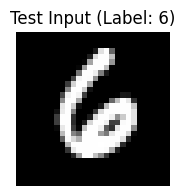

In [76]:
import matplotlib.pyplot as plt

# pick a single test input (the first one in the test dataset)
test_input = test_images[0]
test_label = test_labels[0]

# visualize the test input
plt.figure(figsize=(2, 2))
plt.imshow(test_input.squeeze(), cmap="gray")
plt.title(f"Test Input (Label: {test_label})")
plt.axis("off")
plt.show()

In [ ]:
# External activation capture using forward hooks (model stays unchanged)
from mnist_instrumentation import forward_and_capture_relu

with torch.no_grad():
    x = test_input.unsqueeze(0).to(device)
    output, activations = forward_and_capture_relu(model, x)

print(f"Output: {output.shape}")
print(f"Predicted Label: {output.argmax(dim=1).item()}")

print("\nCaptured activations (after ReLU):")
for name, act in activations.items():
    print(f"  {name}: {act.shape}")


Output: torch.Size([1, 10])
Predicted Label: 6

Captured activations (after ReLU):
  conv1: torch.Size([1, 8, 28, 28])
  conv2: torch.Size([1, 16, 14, 14])
  fc1: torch.Size([1, 32])


In [78]:
def neuron_coverage(activations, threshold=0):
    """
    Calculate neuron coverage from activations.
    A neuron is "covered" if its activation > threshold.
    
    Args:
        activations: Dict of layer activations {name: tensor}
        threshold: Activation threshold (default 0 for ReLU)
    
    Returns:
        coverage: float (0.0 ~ 1.0)
        details: Dict with per-layer coverage info
    """
    total_neurons = 0
    covered_neurons = 0
    details = {}
    
    for name, act in activations.items():
        flat_act = act.view(act.size(0), -1)  # [batch, num_neurons]
        num_neurons = flat_act.shape[1]
        num_covered = (flat_act > threshold).any(dim=0).sum().item()  # covered if any input activates
        
        details[name] = {'covered': num_covered, 'total': num_neurons}
        total_neurons += num_neurons
        covered_neurons += num_covered
    
    coverage = covered_neurons / total_neurons if total_neurons > 0 else 0.0
    return coverage, details

# Calculate neuron coverage
coverage, details = neuron_coverage(activations)

for name, info in details.items():
    print(f"{name}: {info['covered']}/{info['total']} ({100*info['covered']/info['total']:.1f}%)")

print(f"\nTotal Neuron Coverage: {coverage:.1%}")

conv1: 3213/6272 (51.2%)
conv2: 1972/3136 (62.9%)
fc1: 17/32 (53.1%)

Total Neuron Coverage: 55.1%


### Batch Test Cases Exercise

Batch size: 10


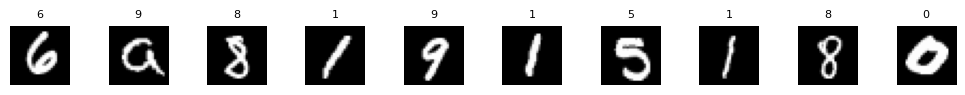

In [79]:
# configurable batch size
BATCH_SIZE = 10

# pick a batch of test inputs
test_inputs = test_images[:BATCH_SIZE]
batch_labels = test_labels[:BATCH_SIZE]

print(f"Batch size: {BATCH_SIZE}")

# visualize all items in compact grid
n_cols = 10
n_rows = (BATCH_SIZE + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
axes = axes.flatten()
for i in range(BATCH_SIZE):
    axes[i].imshow(test_inputs[i].squeeze(), cmap="gray")
    axes[i].set_title(batch_labels[i].item(), fontsize=8)
    axes[i].axis("off")
# hide unused axes
for i in range(BATCH_SIZE, len(axes)):
    axes[i].axis("off")
plt.tight_layout()
plt.show()

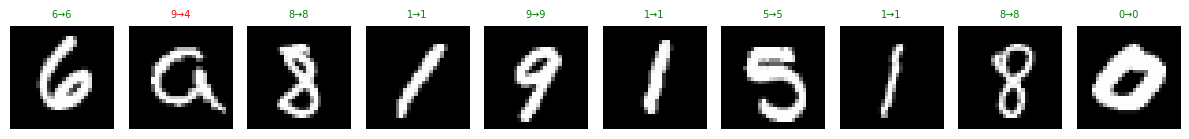

Batch size: 10
Total Neuron Coverage: 75.7%


In [80]:
# get outputs and activations for the full batch
with torch.no_grad():
    outputs, activations = forward_and_capture_relu(model, test_inputs)

predictions = outputs.argmax(dim=1)

# visualize all items with predictions in compact grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.4))
axes = axes.flatten()
for i in range(BATCH_SIZE):
    ax = axes[i]
    ax.imshow(test_inputs[i].squeeze(), cmap="gray")
    label, pred = batch_labels[i].item(), predictions[i].item()
    color = "green" if label == pred else "red"
    ax.set_title(f"{label}→{pred}", fontsize=7, color=color)
    ax.axis("off")
for i in range(BATCH_SIZE, len(axes)):
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# calculate neuron coverage for the full batch
coverage, details = neuron_coverage(activations)

print(f"Batch size: {BATCH_SIZE}")
print(f"Total Neuron Coverage: {coverage:.1%}")

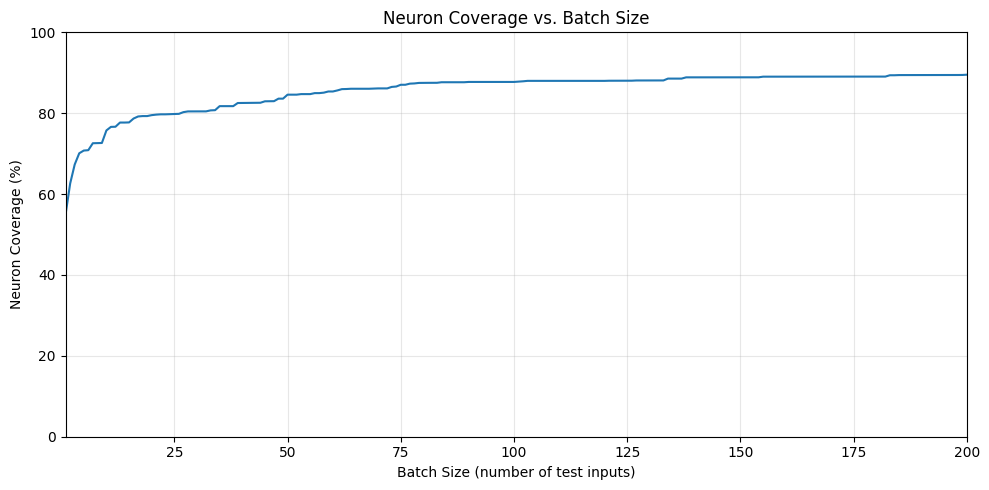

Coverage with 1 input:   55.1%
Coverage with 200 inputs: 89.5%


In [81]:
# Test of increase of neuron coverage with batch size
max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))
coverages = []

with torch.no_grad():
    for size in batch_sizes:
        inputs = test_images[:size].to(device)
        _, activations = forward_and_capture_relu(model, inputs)
        cov, _ = neuron_coverage(activations)
        coverages.append(cov)

# Plot coverage vs batch size
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in coverages], linewidth=1.5)
plt.xlabel("Batch Size (number of test inputs)")
plt.ylabel("Neuron Coverage (%)")
plt.title("Neuron Coverage vs. Batch Size")
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Coverage with 1 input:   {coverages[0]:.1%}")
print(f"Coverage with {max_size} inputs: {coverages[-1]:.1%}")


# Top K Neuron Coverage

# Single Test Case Exercise

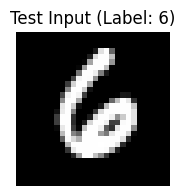

In [91]:
# pick a single test input (the first one in the test dataset)
test_input = test_images[0]
test_label = test_labels[0]

# visualize the test input
plt.figure(figsize=(2, 2))
plt.imshow(test_input.squeeze(), cmap="gray")
plt.title(f"Test Input (Label: {test_label})")
plt.axis("off")
plt.show()

In [92]:
with torch.no_grad():
    x = test_input.unsqueeze(0).to(device)
    output, activations = forward_and_capture_relu(model, x)

print(f"Output: {output.shape}")
print(f"Predicted Label: {output.argmax(dim=1).item()}")

print("\nCaptured activations (after ReLU):")
for name, act in activations.items():
    print(f"  {name}: {act.shape}")

Output: torch.Size([1, 10])
Predicted Label: 6

Captured activations (after ReLU):
  conv1: torch.Size([1, 8, 28, 28])
  conv2: torch.Size([1, 16, 14, 14])
  fc1: torch.Size([1, 32])


In [93]:
def top_k_neuron_coverage(activations, k=0.1, per_filter=True):
    """
    Calculate Top-k Neuron Coverage.
    A neuron is "covered" if it is among the top-k most activated neurons 
    for at least one test input.
    
    Args:
        activations: Dict of layer activations {name: tensor}
        k: Ratio of top neurons to consider (0.0 ~ 1.0).
           e.g., k=0.1 means top 10% of neurons.
        per_filter: If True, pick top-k% within each filter (for conv layers).
                    If False, pick top-k% across entire layer.
    
    Returns:
        coverage: float (0.0 ~ 1.0)
        details: Dict with per-layer coverage info
    """
    total_neurons = 0
    covered_neurons = 0
    details = {}
    
    for name, act in activations.items():
        batch_size = act.size(0)
        
        # Check if conv layer (4D: batch, channels, h, w) or fc layer (2D: batch, neurons)
        if act.dim() == 4 and per_filter:
            # Conv layer: pick top-k% per filter
            # Shape: [batch, channels, h, w] -> [batch, channels, h*w]
            num_filters = act.size(1)
            spatial_size = act.size(2) * act.size(3)
            act_per_filter = act.view(batch_size, num_filters, spatial_size)
            
            # Calculate actual k from ratio (at least 1)
            layer_k = max(1, int(k * spatial_size))
            num_neurons = num_filters * spatial_size
            
            # Track covered neurons per filter
            covered_mask = torch.zeros(num_filters, spatial_size, dtype=torch.bool)
            
            # For each filter, find top-k spatial positions
            _, top_indices = act_per_filter.topk(layer_k, dim=2)  # [batch, filters, k]
            
            for b in range(batch_size):
                for f in range(num_filters):
                    covered_mask[f, top_indices[b, f]] = True
            
            num_covered = covered_mask.sum().item()
            details[name] = {
                'covered': num_covered, 
                'total': num_neurons, 
                'k': layer_k,
                'k_ratio': k,
                'filters': num_filters,
                'per_filter': True
            }
        else:
            # FC layer or per_filter=False: flatten and pick top-k% across all
            flat_act = act.view(batch_size, -1)
            num_neurons = flat_act.shape[1]
            
            # Calculate actual k from ratio (at least 1)
            layer_k = max(1, int(k * num_neurons))
            
            _, top_indices = flat_act.topk(layer_k, dim=1)
            
            covered_mask = torch.zeros(num_neurons, dtype=torch.bool)
            for b in range(batch_size):
                covered_mask[top_indices[b]] = True
            
            num_covered = covered_mask.sum().item()
            details[name] = {
                'covered': num_covered, 
                'total': num_neurons, 
                'k': layer_k,
                'k_ratio': k,
                'per_filter': False
            }
        
        total_neurons += num_neurons
        covered_neurons += num_covered
    
    coverage = covered_neurons / total_neurons if total_neurons > 0 else 0.0
    return coverage, details

# Calculate top-k neuron coverage (k=10%, per-filter for conv layers)
K_RATIO = 0.1  # top 10%
coverage, details = top_k_neuron_coverage(activations, k=K_RATIO, per_filter=True)

print(f"Top-{K_RATIO:.0%} Neuron Coverage (per-filter for conv layers):")
for name, info in details.items():
    if info.get('per_filter'):
        print(f"  {name}: {info['covered']}/{info['total']} ({100*info['covered']/info['total']:.1f}%) "
              f"[{info['filters']} filters × top-{info['k']} ({info['k_ratio']:.0%} of {info['total']//info['filters']})]")
    else:
        print(f"  {name}: {info['covered']}/{info['total']} ({100*info['covered']/info['total']:.1f}%) "
              f"[top-{info['k']} ({info['k_ratio']:.0%} of {info['total']})]")

print(f"\nTotal Top-{K_RATIO:.0%} Neuron Coverage: {coverage:.1%}")

Top-10% Neuron Coverage (per-filter for conv layers):
  conv1: 624/6272 (9.9%) [8 filters × top-78 (10% of 784)]
  conv2: 304/3136 (9.7%) [16 filters × top-19 (10% of 196)]
  fc1: 3/32 (9.4%) [top-3 (10% of 32)]

Total Top-10% Neuron Coverage: 9.9%


# Batch Test Cases Exercise

In [95]:
# configurable batch size
BATCH_SIZE = 10

# pick a batch of test inputs
test_inputs = test_images[:BATCH_SIZE]
batch_labels = test_labels[:BATCH_SIZE]

print(f"Batch size: {BATCH_SIZE}")

# get outputs and activations for the full batch
with torch.no_grad():
    outputs, activations = forward_and_capture_relu(model, test_inputs)


# calculate top-k neuron coverage for the full batch
K_RATIO = 0.1  # top 10%
coverage, details = top_k_neuron_coverage(activations, k=K_RATIO, per_filter=True)

print(f"Batch size: {BATCH_SIZE}")
print(f"Total Top-K Neuron Coverage: {coverage:.1%}")

Batch size: 10
Batch size: 10
Total Top-K Neuron Coverage: 34.9%


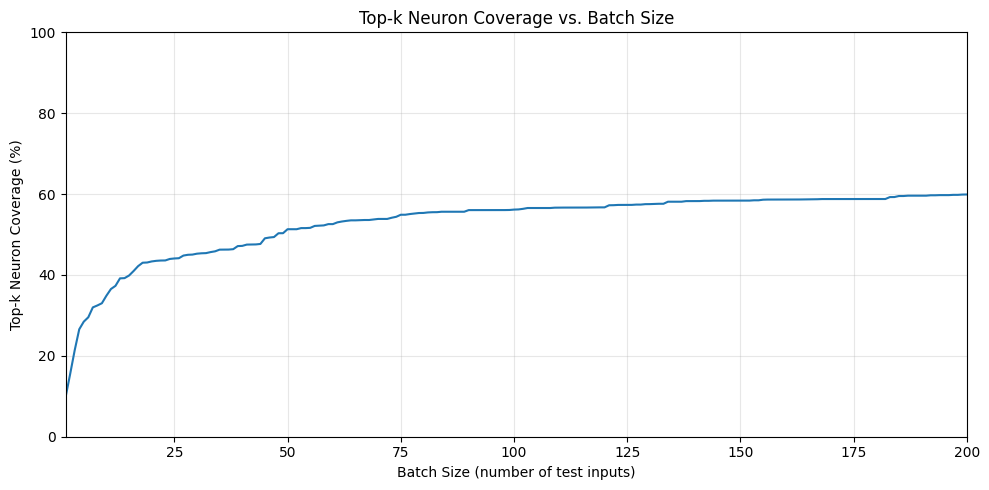

Coverage with 1 input:   9.9%
Coverage with 200 inputs: 59.9%


In [96]:
# Test of increase of top-k neuron coverage with batch size
max_size = len(test_images)
batch_sizes = list(range(1, max_size + 1))
coverages = []

K_RATIO = 0.1  # top 10%
with torch.no_grad():
    for size in batch_sizes:
        inputs = test_images[:size].to(device)
        _, activations = forward_and_capture_relu(model, inputs)
        cov, _ = top_k_neuron_coverage(activations, k=K_RATIO, per_filter=True)
        coverages.append(cov)

# Plot coverage vs batch size
plt.figure(figsize=(10, 5))
plt.plot(batch_sizes, [c * 100 for c in coverages], linewidth=1.5)
plt.xlabel("Batch Size (number of test inputs)")
plt.ylabel("Top-k Neuron Coverage (%)")
plt.title("Top-k Neuron Coverage vs. Batch Size")
plt.grid(True, alpha=0.3)
plt.xlim(1, max_size)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

print(f"Coverage with 1 input:   {coverages[0]:.1%}")
print(f"Coverage with {max_size} inputs: {coverages[-1]:.1%}")


# 🏆 Challenge: Manual Test Optimization

Select **20 test inputs** from `test_images` (indices 0-199) to maximize Top-10% Neuron Coverage.

This is a preview of the **Test Optimization** problem, which we'll cover later.

**Baseline**: First 20 images [0:19]. Can you beat it?